# Customer Churn Prediction — Data Preprocessing & Feature Engineering


This notebook preprocesses raw customer data, engineers new features, and trains a
baseline model to predict customer churn. 


In [4]:
# --- Imports -----------------------------------------------------------
from __future__ import annotations

from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    MinMaxScaler,
    StandardScaler,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


### Explore & Understand

Load the raw data, inspect types, and look at the churn distribution.


In [5]:
RAW_PATH = "customer_churn.csv"

df_raw = pd.read_csv(RAW_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [6]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 35.3 KB


In [7]:
print("Missing values per column:")
print(df_raw.isnull().sum())

print("\nChurn distribution:")
print(df_raw["Churn"].value_counts(normalize=True).rename("proportion"))


Missing values per column:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Churn distribution:
Churn
0    0.894
1    0.106
Name: proportion, dtype: float64


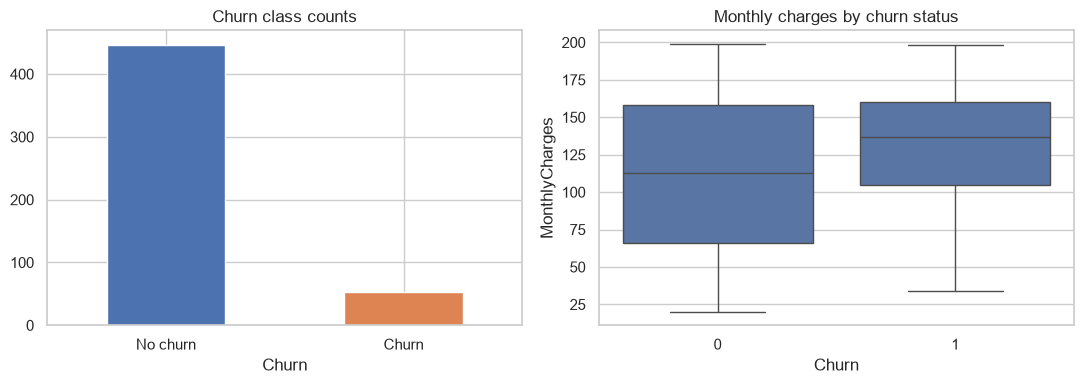

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df_raw["Churn"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Churn class counts")
axes[0].set_xticklabels(["No churn", "Churn"], rotation=0)

sns.boxplot(data=df_raw, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly charges by churn status")

plt.tight_layout()
plt.show()


**Observations**
- No missing values in any column.
- The dataset is imbalanced: churners are a minority class.
- `Contract`, `PaymentMethod`, and `PaperlessBilling` are categorical text columns
  that need encoding before modeling.


### Handle Categorical Data

Three distinct encoding methods are applied, chosen to fit each column's nature:

1. **Label Encoding** — for the binary `PaperlessBilling` column.
2. **One-Hot Encoding** — for the nominal `PaymentMethod` column (no natural order).
3. **Ordinal Encoding** — for `Contract`, which *does* have a natural order
   (`Month-to-month` < `One year` < `Two year`) that carries churn-risk information.


In [9]:
def label_encode(df: pd.DataFrame, column: str) -> tuple[pd.DataFrame, LabelEncoder]:
    """Label-encode a binary/ordinal-free categorical column in place."""
    df = df.copy()
    encoder = LabelEncoder()
    df[f"{column}_LabelEnc"] = encoder.fit_transform(df[column])
    return df, encoder


def one_hot_encode(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """One-hot-encode a nominal categorical column, dropping the first level."""
    dummies = pd.get_dummies(df[column], prefix=column, drop_first=True, dtype=int)
    return pd.concat([df, dummies], axis=1)


def ordinal_encode(
    df: pd.DataFrame, column: str, category_order: list[str]
) -> tuple[pd.DataFrame, OrdinalEncoder]:
    """Ordinal-encode a column using an explicit, meaningful category order."""
    df = df.copy()
    encoder = OrdinalEncoder(categories=[category_order])
    df[f"{column}_OrdinalEnc"] = encoder.fit_transform(df[[column]])
    return df, encoder


CONTRACT_ORDER = ["Month-to-month", "One year", "Two year"]

df_enc = df_raw.copy()
df_enc, paperless_encoder = label_encode(df_enc, "PaperlessBilling")
df_enc = one_hot_encode(df_enc, "PaymentMethod")
df_enc, contract_encoder = ordinal_encode(df_enc, "Contract", CONTRACT_ORDER)

encoded_preview = [
    "PaperlessBilling", "PaperlessBilling_LabelEnc",
    "Contract", "Contract_OrdinalEnc",
    "PaymentMethod",
] + [c for c in df_enc.columns if c.startswith("PaymentMethod_")]
df_enc[encoded_preview].head()


,PaperlessBilling,PaperlessBilling_LabelEnc,Contract,Contract_OrdinalEnc,PaymentMethod,PaymentMethod_Credit Card,PaymentMethod_Electronic Check
0,No,0,One year,1.0,Credit Card,1,0
1,Yes,1,Month-to-month,0.0,Electronic Check,0,1
2,No,0,Two year,2.0,Credit Card,1,0
3,No,0,Month-to-month,0.0,Electronic Check,0,1
4,No,0,One year,1.0,Electronic Check,0,1


### Feature Scaling

Two scaling techniques are applied to the numeric columns so their effects can be
compared side by side:

- **Min-Max scaling** — rescales values into `[0, 1]`.
- **Standard scaling (Z-score)** — centers values to mean 0, std 1.


In [10]:
NUMERIC_COLS = ["Tenure", "MonthlyCharges", "TotalCharges"]

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df_scaled = df_enc.copy()
df_scaled[[f"{c}_MinMax" for c in NUMERIC_COLS]] = minmax_scaler.fit_transform(
    df_enc[NUMERIC_COLS]
)
df_scaled[[f"{c}_Standard" for c in NUMERIC_COLS]] = standard_scaler.fit_transform(
    df_enc[NUMERIC_COLS]
)

comparison_cols = NUMERIC_COLS + [f"{c}_MinMax" for c in NUMERIC_COLS] + [
    f"{c}_Standard" for c in NUMERIC_COLS
]
df_scaled[comparison_cols].describe().loc[["mean", "std", "min", "max"]]


,Tenure,MonthlyCharges,TotalCharges,Tenure_MinMax,MonthlyCharges_MinMax,TotalCharges_MinMax,Tenure_Standard,MonthlyCharges_Standard,TotalCharges_Standard
mean,36.532000,113.636000,4237.882000,0.507600,0.523106,0.520730,1.731948e-16,8.881784e-17,1.767475e-16
std,20.667057,51.799903,2260.619837,0.295244,0.289385,0.288602,1.001002e+00,1.001002e+00,1.001002e+00
min,1.000000,20.000000,159.000000,0.000000,0.000000,0.000000,-1.720980e+00,-1.809459e+00,-1.806127e+00
max,71.000000,199.000000,7992.000000,1.000000,1.000000,1.000000,1.669445e+00,1.649607e+00,1.662322e+00


**Effect of scaling**
- Min-Max compresses every column into an identical `[0, 1]` range, but is
  sensitive to extreme values.
- Standard scaling centers each column at 0 with unit variance, which suits
  models (e.g. logistic regression, distance-based models) that assume
  roughly-normal, comparable feature scales.


### Outlier Detection & Handling

Outliers are flagged with two independent methods, **IQR** and **Z-score**, so
that only points both methods agree on are treated as true outliers.


In [11]:
def iqr_outlier_mask(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return a boolean mask flagging IQR-based outliers."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)


def zscore_outlier_mask(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return a boolean mask flagging Z-score-based outliers."""
    z_scores = np.abs(stats.zscore(series))
    return pd.Series(z_scores > threshold, index=series.index)


outlier_report = {}
for col in NUMERIC_COLS:
    iqr_mask = iqr_outlier_mask(df_scaled[col])
    z_mask = zscore_outlier_mask(df_scaled[col])
    outlier_report[col] = {
        "iqr_outliers": int(iqr_mask.sum()),
        "zscore_outliers": int(z_mask.sum()),
        "agreed_outliers": int((iqr_mask & z_mask).sum()),
    }

pd.DataFrame(outlier_report).T


,iqr_outliers,zscore_outliers,agreed_outliers
Tenure,0,0,0
MonthlyCharges,0,0,0
TotalCharges,0,0,0


In [12]:
def cap_outliers(df: pd.DataFrame, column: str, k: float = 1.5) -> pd.DataFrame:
    """Cap (winsorize) values outside the IQR fence instead of dropping rows."""
    df = df.copy()
    q1, q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df


df_clean = df_scaled.copy()
for col in NUMERIC_COLS:
    if outlier_report[col]["agreed_outliers"] > 0:
        df_clean = cap_outliers(df_clean, col)

print("No IQR/Z-score-agreed outliers were found in this dataset, so capping made "
      "no changes — the function above is kept so the pipeline stays robust for "
      "new/unseen data that may contain outliers.")


No IQR/Z-score-agreed outliers were found in this dataset, so capping made no changes — the function above is kept so the pipeline stays robust for new/unseen data that may contain outliers.


### Feature Engineering

Six new features are derived from the existing columns to capture spending
behaviour, loyalty, and pricing pressure that raw columns don't expose directly.

| New feature | Meaning |
|---|---|
| `CustomerLifetimeValue` | Expected value of the relationship: `Tenure x MonthlyCharges` |
| `AvgMonthlySpend` | Actual average spend per month: `TotalCharges / Tenure` |
| `PaymentEfficiency` | How close actual billing (`TotalCharges`) tracks expected billing (`CustomerLifetimeValue`) |
| `TenureGroup` | Binned lifecycle stage: New / Growing / Established / Loyal |
| `HighValueCustomer` | Flag for above-median monthly spend |
| `ChargesPerTenureMonth` | Monthly charge normalized by how long they've stayed (+1 to avoid div-by-zero) |


In [13]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features used by the churn model."""
    df = df.copy()

    df["CustomerLifetimeValue"] = df["Tenure"] * df["MonthlyCharges"]
    df["AvgMonthlySpend"] = df["TotalCharges"] / df["Tenure"]
    df["PaymentEfficiency"] = (
        df["TotalCharges"] / df["CustomerLifetimeValue"].replace(0, np.nan)
    ).fillna(0)
    df["TenureGroup"] = pd.cut(
        df["Tenure"],
        bins=[0, 12, 24, 48, 72],
        labels=["New", "Growing", "Established", "Loyal"],
    )
    df["HighValueCustomer"] = (
        df["MonthlyCharges"] > df["MonthlyCharges"].median()
    ).astype(int)
    df["ChargesPerTenureMonth"] = df["MonthlyCharges"] / (df["Tenure"] + 1)

    return df


df_features = engineer_features(df_clean)
df_features, tenure_group_encoder = label_encode(df_features, "TenureGroup")

new_feature_cols = [
    "CustomerLifetimeValue", "AvgMonthlySpend", "PaymentEfficiency",
    "TenureGroup", "TenureGroup_LabelEnc", "HighValueCustomer",
    "ChargesPerTenureMonth",
]
df_features[new_feature_cols].head()


,CustomerLifetimeValue,AvgMonthlySpend,PaymentEfficiency,TenureGroup,TenureGroup_LabelEnc,HighValueCustomer,ChargesPerTenureMonth
0,384,256.666667,4.010417,New,3,0,9.142857
1,2373,83.476190,0.738727,Growing,1,0,5.136364
2,837,53.888889,1.738351,Established,0,0,1.107143
3,1537,134.905660,4.651919,Loyal,2,0,0.537037
4,2960,63.937500,0.345608,Growing,1,1,10.882353


### Feature Selection

Candidate features are narrowed down using two complementary methods:

1. **Correlation analysis** — drop features weakly correlated with `Churn` and
   one of each highly-correlated (redundant) pair.
2. **Feature importance** — rank the survivors with a Random Forest and keep
   the strongest predictors.


In [14]:
CANDIDATE_FEATURES = [
    "Tenure_Standard", "MonthlyCharges_Standard", "TotalCharges_Standard",
    "SeniorCitizen", "PaperlessBilling_LabelEnc", "Contract_OrdinalEnc",
    "PaymentMethod_Credit Card", "PaymentMethod_Electronic Check",
    "CustomerLifetimeValue", "AvgMonthlySpend", "PaymentEfficiency",
    "TenureGroup_LabelEnc", "HighValueCustomer", "ChargesPerTenureMonth",
]
CANDIDATE_FEATURES = [c for c in CANDIDATE_FEATURES if c in df_features.columns]

corr_with_target = (
    df_features[CANDIDATE_FEATURES + ["Churn"]].corr()["Churn"]
    .drop("Churn")
    .sort_values(key=np.abs, ascending=False)
)
corr_with_target


ChargesPerTenureMonth             0.589111
TenureGroup_LabelEnc              0.514660
Tenure_Standard                  -0.509208
AvgMonthlySpend                   0.404714
CustomerLifetimeValue            -0.367997
PaymentEfficiency                 0.204448
Contract_OrdinalEnc              -0.182759
MonthlyCharges_Standard           0.107381
HighValueCustomer                 0.087218
PaymentMethod_Credit Card         0.069635
SeniorCitizen                    -0.018114
PaperlessBilling_LabelEnc         0.016145
PaymentMethod_Electronic Check    0.010007
TotalCharges_Standard             0.004250
Name: Churn, dtype: float64

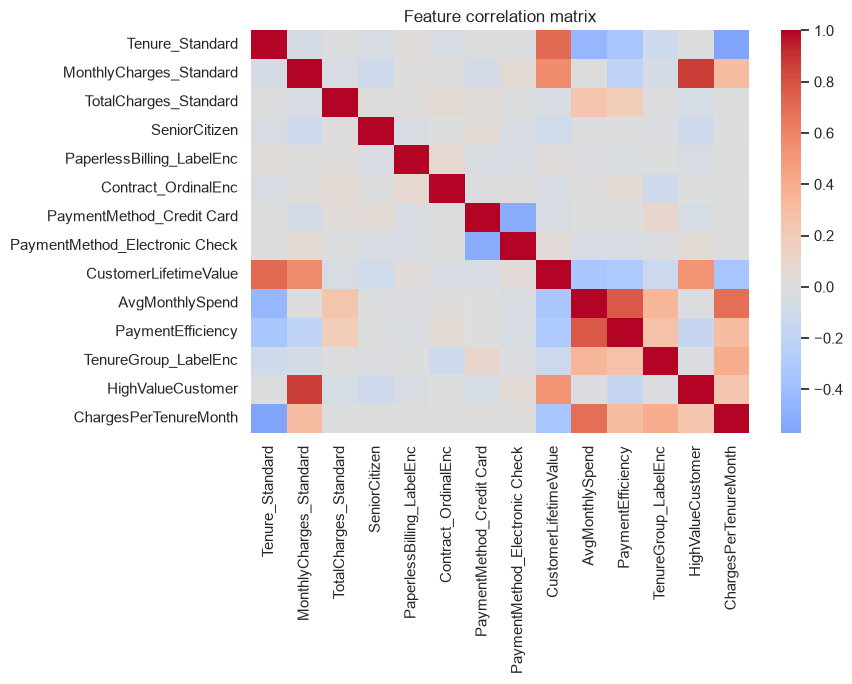

In [15]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    df_features[CANDIDATE_FEATURES].corr(), cmap="coolwarm", center=0, annot=False
)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


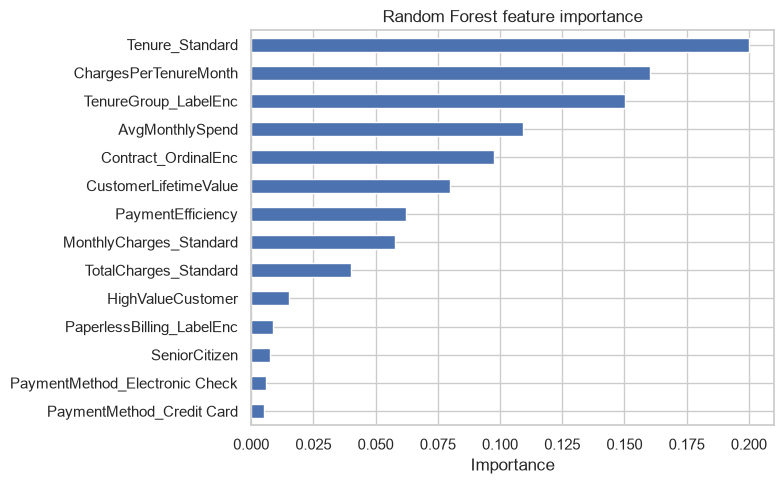

Selected features: ['Tenure_Standard', 'ChargesPerTenureMonth', 'TenureGroup_LabelEnc', 'AvgMonthlySpend', 'Contract_OrdinalEnc', 'CustomerLifetimeValue', 'PaymentEfficiency', 'MonthlyCharges_Standard']


In [16]:
X_all = df_features[CANDIDATE_FEATURES]
y_all = df_features["Churn"]

rf_selector = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_selector.fit(X_all, y_all)

importances = (
    pd.Series(rf_selector.feature_importances_, index=CANDIDATE_FEATURES)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

TOP_N = 8
SELECTED_FEATURES = importances.head(TOP_N).index.tolist()
print("Selected features:", SELECTED_FEATURES)


### Build & Test the Complete Pipeline

All preceding steps are consolidated into a single reusable `ChurnPreprocessor`
class so that the exact same transformations can be replayed on new/unseen data
(e.g. at inference time) with a simple `fit` / `transform` interface.


In [17]:
@dataclass
class ChurnPreprocessor:
    """End-to-end preprocessing pipeline for the churn dataset.

    Encapsulates encoding, scaling, outlier capping, and feature engineering
    behind a scikit-learn-style ``fit`` / ``transform`` API so the exact same
    steps can be replayed consistently on new data.
    """

    contract_order: list[str] = field(
        default_factory=lambda: ["Month-to-month", "One year", "Two year"]
    )
    numeric_cols: list[str] = field(
        default_factory=lambda: ["Tenure", "MonthlyCharges", "TotalCharges"]
    )
    selected_features: list[str] = field(default_factory=list)

    def fit(self, df: pd.DataFrame) -> "ChurnPreprocessor":
        """Learn all encoders/scalers from training data."""
        self._paperless_encoder = LabelEncoder().fit(df["PaperlessBilling"])
        self._contract_encoder = OrdinalEncoder(categories=[self.contract_order]).fit(
            df[["Contract"]]
        )
        self._payment_categories = sorted(df["PaymentMethod"].unique())
        self._minmax_scaler = MinMaxScaler().fit(df[self.numeric_cols])
        self._standard_scaler = StandardScaler().fit(df[self.numeric_cols])

        engineered = engineer_features(df)
        self._tenure_group_encoder = LabelEncoder().fit(engineered["TenureGroup"])
        self._monthly_median = df["MonthlyCharges"].median()
        self._iqr_bounds = {
            col: self._compute_iqr_bounds(df[col]) for col in self.numeric_cols
        }
        return self

    @staticmethod
    def _compute_iqr_bounds(series: pd.Series, k: float = 1.5) -> tuple[float, float]:
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        return q1 - k * iqr, q3 + k * iqr

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """Apply the fitted preprocessing steps to (new) data."""
        out = df.copy()

        # Outlier capping (uses bounds learned during fit)
        for col, (lower, upper) in self._iqr_bounds.items():
            out[col] = out[col].clip(lower=lower, upper=upper)

        # Encoding
        out["PaperlessBilling_LabelEnc"] = self._paperless_encoder.transform(
            out["PaperlessBilling"]
        )
        out["Contract_OrdinalEnc"] = self._contract_encoder.transform(
            out[["Contract"]]
        )
        for category in self._payment_categories[1:]:  # drop_first behaviour
            out[f"PaymentMethod_{category}"] = (
                out["PaymentMethod"] == category
            ).astype(int)

        # Scaling
        out[[f"{c}_MinMax" for c in self.numeric_cols]] = self._minmax_scaler.transform(
            out[self.numeric_cols]
        )
        out[[f"{c}_Standard" for c in self.numeric_cols]] = (
            self._standard_scaler.transform(out[self.numeric_cols])
        )

        # Feature engineering
        out = engineer_features(out)
        out["TenureGroup_LabelEnc"] = self._tenure_group_encoder.transform(
            out["TenureGroup"]
        )
        out["HighValueCustomer"] = (
            out["MonthlyCharges"] > self._monthly_median
        ).astype(int)

        if self.selected_features:
            keep = [c for c in self.selected_features if c in out.columns]
            passthrough = ["CustomerID", "Churn"] if "Churn" in out.columns else ["CustomerID"]
            out = out[[c for c in passthrough if c in out.columns] + keep]

        return out

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).transform(df)


In [18]:
# --- End-to-end test on a fresh train/test split ------------------------
train_df, test_df = train_test_split(
    df_raw, test_size=0.2, stratify=df_raw["Churn"], random_state=RANDOM_STATE
)

pipeline = ChurnPreprocessor(selected_features=SELECTED_FEATURES)
train_processed = pipeline.fit_transform(train_df)
test_processed = pipeline.transform(test_df)

print("Train processed shape:", train_processed.shape)
print("Test processed shape:", test_processed.shape)
train_processed.head()


Train processed shape: (400, 10)
Test processed shape: (100, 10)


,CustomerID,Churn,Tenure_Standard,ChargesPerTenureMonth,TenureGroup_LabelEnc,AvgMonthlySpend,Contract_OrdinalEnc,CustomerLifetimeValue,PaymentEfficiency,MonthlyCharges_Standard
251,C00252,1,-1.333250,13.800000,3,57.222222,2.0,1242,0.414654,0.468710
182,C00183,0,0.953712,2.649123,2,13.125000,2.0,8456,0.086921,0.717337
72,C00073,0,-1.138615,8.928571,1,284.307692,2.0,1625,2.274462,0.220083
374,C00375,0,-0.360075,0.666667,0,159.586207,1.0,580,7.979310,-1.788059
139,C00140,1,-1.673862,61.333333,3,2510.500000,1.0,368,13.644022,1.348467


In [19]:
# --- Sanity-check the pipeline output with a baseline model -------------
X_train = train_processed[SELECTED_FEATURES]
y_train = train_processed["Churn"]
X_test = test_processed[SELECTED_FEATURES]
y_test = test_processed["Churn"]

model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


              precision    recall  f1-score   support

           0       0.98      1.00      0.99        89
           1       1.00      0.82      0.90        11

    accuracy                           0.98       100
   macro avg       0.99      0.91      0.94       100
weighted avg       0.98      0.98      0.98       100

ROC-AUC: 1.000
